# 📊 Optimization Methods Assignment
## Asset Portfolio Optimization

### Group Members:
- Student 1: Chaya Kotuvila_MS25942316
- Student 2: Dilesha Wijayathilaka_MS25941876

### Module:
MSc Artificial Intelligence – Optimization Methods

---

## 🎯 Objective
This project aims to solve a real-world portfolio optimization problem using:
- Exact optimization method (SciPy SLSQP)
- Heuristic method (Genetic Algorithm)

We compare solution quality, runtime, and feasibility.

## 🧩 Problem Description

We aim to allocate capital across multiple financial assets to:

- Minimize portfolio risk (variance)
- Achieve a target return

This is a **resource allocation optimization problem**.

---

## 📊 Dataset

We use real-world financial data from Yahoo Finance:

Assets:
- Apple (AAPL)
- Microsoft (MSFT)
- Amazon (AMZN)
- Google (GOOGL)
- Tesla (TSLA)
- Netflix (NFLX)
- Bitcoin (BTC-USD)

Time Period: 2021–2026

Data is used to compute statistical properties (returns, covariance), not for training.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
from scipy.optimize import minimize

In [3]:
# =========================================================
# 1. Real-world Data Extraction (2021–2026)
# =========================================================

# Asset list
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NFLX', 'BTC-USD']
data = yf.download(tickers, start="2021-01-01", end=datetime.now().strftime('%Y-%m-%d'))['Close']

# --- Before Cleaning ---
print(data.isnull().sum())
display(data.tail())

# --- Cleaning Process ---
# 1. Forward Fill
# 2. Dropna
data = data.ffill().dropna()

# --- After Cleaning ---
print(data.isnull().sum())
display(data.tail())

# --- Save ---
data.to_csv('portfolio_data_2026.csv')

/tmp/ipykernel_1225/3494108579.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2021-01-01", end=datetime.now().strftime('%Y-%m-%d'))['Close']
[*********************100%***********************]  7 of 7 completed

Ticker
AAPL       605
AMZN       605
BTC-USD      0
GOOGL      605
MSFT       605
NFLX       605
TSLA       605
dtype: int64


Ticker,AAPL,AMZN,BTC-USD,GOOGL,MSFT,NFLX,TSLA
Date,,,,,,,
2026-04-08,258.899994,221.250000,71123.359375,317.320007,374.329987,99.389999,343.250000
2026-04-09,260.489990,233.649994,71767.828125,318.489990,373.070007,102.050003,345.619995
2026-04-10,260.480011,238.380005,72979.046875,317.239990,370.869995,103.010002,348.950012
2026-04-11,NaN,NaN,73054.273438,NaN,NaN,NaN,NaN
2026-04-12,NaN,NaN,70753.406250,NaN,NaN,NaN,NaN


Ticker
AAPL       0
AMZN       0
BTC-USD    0
GOOGL      0
MSFT       0
NFLX       0
TSLA       0
dtype: int64


Ticker,AAPL,AMZN,BTC-USD,GOOGL,MSFT,NFLX,TSLA
Date,,,,,,,
2026-04-08,258.899994,221.250000,71123.359375,317.320007,374.329987,99.389999,343.250000
2026-04-09,260.489990,233.649994,71767.828125,318.489990,373.070007,102.050003,345.619995
2026-04-10,260.480011,238.380005,72979.046875,317.239990,370.869995,103.010002,348.950012
2026-04-11,260.480011,238.380005,73054.273438,317.239990,370.869995,103.010002,348.950012
2026-04-12,260.480011,238.380005,70753.406250,317.239990,370.869995,103.010002,348.950012


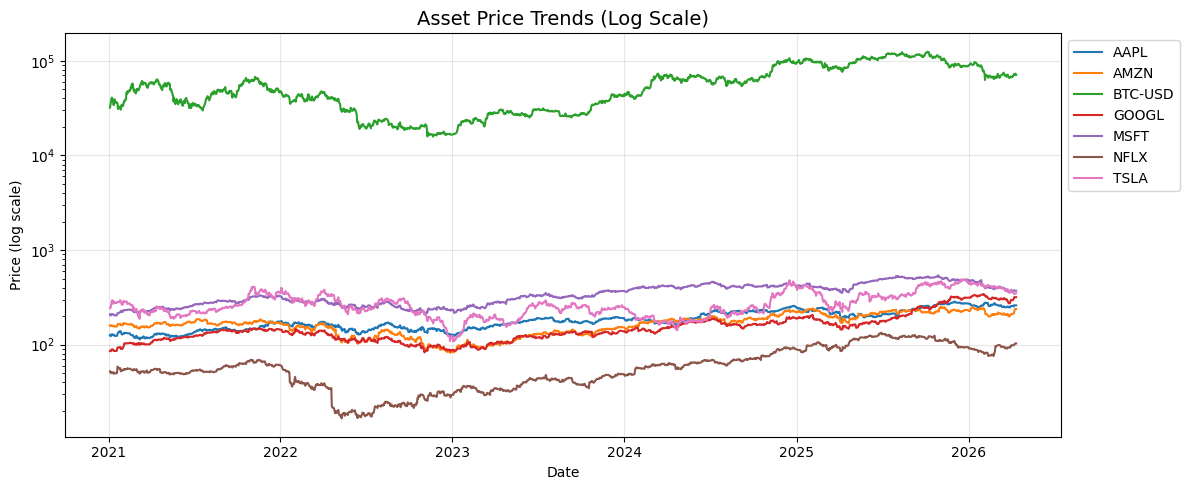

In [4]:
# =========================================================
# 2. Asset Price Visualization (Log Scale)
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.yscale('log')  # comparing assets with different scales

plt.title("Asset Price Trends (Log Scale)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (log scale)")

plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Sample Returns ===
Ticker          AAPL      AMZN   BTC-USD     GOOGL      MSFT      NFLX  \
Date                                                                     
2021-01-05  0.012364  0.010004  0.063197  0.008064  0.000965 -0.003940   
2021-01-06 -0.033662 -0.024897  0.083311 -0.009868 -0.025929 -0.038998   
2021-01-07  0.034123  0.007577  0.069157  0.029869  0.028457  0.016784   
2021-01-08  0.008631  0.006496  0.036234  0.013239  0.006093  0.002967   
2021-01-09  0.000000  0.000000 -0.013311  0.000000  0.000000  0.000000   

Ticker          TSLA  
Date                  
2021-01-05  0.007317  
2021-01-06  0.028390  
2021-01-07  0.079447  
2021-01-08  0.078403  
2021-01-09  0.000000  


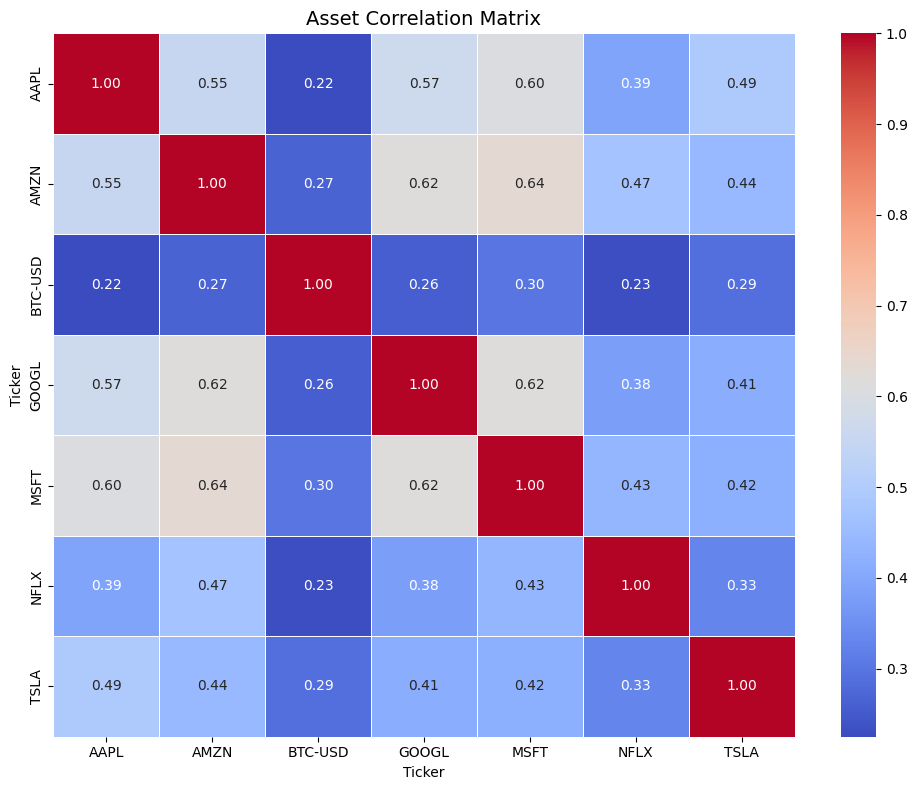

In [5]:
# =========================================================
# 3. Return Calculation & Correlation Analysis
# =========================================================

import seaborn as sns

# Daily returns
returns = data.pct_change().dropna()

print("=== Sample Returns ===")
print(returns.head())

# Correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Asset Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()